# Progetto del corso - Introduzione alla Data Science e al pensiero computazionale - a.a. 2025/2026

# Membri del gruppo numero 12

Il gruppo numero 12 è composto da:

*   **Nicoletta Aloisi:** matricola 1216124, email nicoletta.aloisi@studio.unibo.it
*   **Erika Avdiaj:** matricola 1226030, email erika.avdiaj@studio.unibo.it
*   **Giannalisa Romeo:** matricola 1216078, email giannalisa.romeo@studio.unibo.it

# Materiale del progetto

Il materiale del progetto è disponibile sul sito del corso e contiene i seguenti dataset:

* *Bank_Marketing*
* *Credit_Card_Default*
* *Customer_Churn*
* *Employee_Attrition* (**noi abbiamo scelto questo dataset**: dobbiamo predire l'abbandono dei dipendenti; variabile target: Attrition)
* *Online_Shoppers*


# Fase 1 - Setup Progetto e repository Github
* Struttura cartelle: data/ , notebooks/ , figures/ , report/ , README.md
* README.md con: descrizione progetto, descrizione dataset, obiettivo, modelli usati, istruzioni d'esecuzione, membri del gruppo
* Requisiti Git: ≥10 commit, messaggi significativi, almeno 1 branch per membro, almeno 1 merge

# Fase 2 - Descrizione e comprensione del dataset
* Capire struttura, distribuzioni, qualità, limiti, possibili problemi
* Minimo: 8 domande/ipotesi, 5 statistiche descrittive, 3 riflessioni critiche (es. class imbalance, outlier, feature correlate, dati mancanti, feature sospette)

**Preparazione dell'ambiente**


Prima di iniziare questa parte dobbiamo preparare l'ambiente Colab importando **Pandas**, **Seaborn** e **Scikit-learn**.

In [2]:
# Pandas
import pandas as pd
import numpy as np

# Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn import svm, tree
from sklearn.metrics import *

In [4]:
train = pd.read_csv("sample_data/Employee_Attrition.csv", sep=",")
variabili_categoriche = pd.read_csv("sample_data/Employee_Attrition_Description.csv", sep=",")

In [14]:
train.head()  #le prime 5 righe del dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
train.shape   #quante righe e colonne

(1470, 35)

Il dataset di training include 1470 osservazioni e 35 variabili.

In [19]:
train.dtypes   #tipo di dato per ogni colonna

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


L'analisi dei tipi di dato mostra che le variabili del dataset sono numeriche intere o categoriche.

In [15]:
train.isnull().sum()    #quanti valori mancanti

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Non sono presenti valori mancanti nel dataset.

#5 statistiche descrittive

In [21]:
train.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Dall'analisi delle principali statistiche, si possono osservare:
1. Age: mediana (36 anni) e media (36,9 anni) risultano simmetriche. La maggior parte dei dipendenti (il 50%) è tra 30 e 43 anni.

ISTOGRAMMA O BOXPLOT

2. Distance From Home: la media (9,2) è maggiore della mediana (7), suggerendo che alcuni dipendenti (outlier) abitino lontano dal luogo di lavoro.

BOXPLOT

3. Monthly Income: la media (6503) è molto maggiore della mediana (4919), suggerendo una distribuzione asimmetrice verso destra, con pochi dipendenti con stipendi elevati (outlier)  che alzano inevitabimlente la media.

BOXPLOT

4. Total Working Years: la media indica che generalmente gli anni di lavoro complessivi corrispondano a 11,3 anni; da confrontare con Years At Company: la media di 7 anni e la mediana di 5 anni indicano che molti dipendenti lavorano nell'azienda attuale da relativamente poco tempo; solo una minoranza è presente da decenni.

BOXPLOT

5. Job Satisfaction ha una media di 2,7 su 4, stazionandosi su un livello medio - vedremo se la soddisfazione lavorativa influenza o meno l'abbandono dell'azienda.

#8 domande/ipotesi

*1. La variabile target (*Attrition*) è bilanciata?*

In [10]:
train['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


Class imbalance: La stragrande maggioranza dei dipendenti ha continuato a lavorare in azienda (84%). Il 16% dei dipendenti, invece, ha lasciato il proprio posto di lavoro.

*2. I dipendenti che fanno straordinari (Over Time) lasciano più frequentemente l'azienda?*

In [25]:
pd.crosstab(train['OverTime'], train['Attrition'], normalize='index')*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Il 30% dei dipendenti che fanno straordinari lascia l'azienda; mentre, per coloro che non svolgono straordinari, solo il 10% lascia l'azienda. Dunque, gli straordinari possono influire nell'incentivare ad abbandonare l'azienda.

*3. Uno stipendio mensile più basso aumenta la probabilità di Attrition?*

In [29]:
train.groupby('Attrition')['MonthlyIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


Si nota che, i dipendenti che abbandonano l'azienda hanno uno stipendio mediamente più basso rispetto a coloro che rimangono (il 75% dei dipendenti che lasciano l'azienda guadagna 5916 euro al mese vs gli 8834 euro al mese guadagnati da coloro che lavorano).

*4. I dipendenti più giovani abbandonano più spesso l'azienda?*

In [30]:
train.groupby('Attrition')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


I dipendenti che lasciano l'azienda sono mediamente più giovani (33 anni); mentre coloro che continuano a lavorare hanno mediamente 37 anni. Si potrebbe ipotizzare che i più giovani vogliano fare carriera altrove, magari non avendo ancora un ruolo importante in azienda o uno stipendio ritenuto soddisfacente.

*5. Una maggiore distanza da casa aumenta il rischio di dimissioni?*

In [34]:
train.groupby('Attrition')['DistanceFromHome'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,8.915653,8.012633,1.0,2.0,7.0,13.0,29.0
Yes,237.0,10.632911,8.452525,1.0,3.0,9.0,17.0,29.0


Si può notare come il 75% dei dipendenti che lasciano l'azienda sia più distante dalla propria casa in confronto al 75% di coloro che continuano a lavorare (17km di distanza vs 13km).

*6. La soddisfazione lavorativa (Job Satisfaction) è associata all'Attrition?*

In [36]:
pd.crosstab(train['JobSatisfaction'], train['Attrition'], normalize="index")*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Si può osservare come la stragrande maggioranza di coloro che continuano a lavorare (88%) si ritiene molto soddisfatto del proprio lavoro. Contrariamente solo l'11% di coloro che hanno abbandonato l'azienda si definisce pienamente soddisfatto del lavoro; percentuale che si alza fino al 23% per coloro che hanno abbandonato l'azienda e non erano minimamente soddisfatti. Dunque, essere soddisfatti del proprio lavoro può incidere nella decisione di lasciare l'azienda.



*7. Il livello del ruolo (Job Level) influenza l'Attrition?*

In [37]:
pd.crosstab(train['JobLevel'], train['Attrition'], normalize='index')*100

Attrition,No,Yes
JobLevel,,
1,73.664825,26.335175
2,90.262172,9.737828
3,85.321101,14.678899
4,95.283019,4.716981
5,92.753623,7.246377


Si vede che all'aumentare del ruolo nella scala di importanza, diminuisce la percentuale di persone che hanno lasciato l'azienda (dal 26% di dipendenti con ruoli di basso livello che hanno abbandonato il lavoro, fino al 7% di persone con ruoli apicali che hanno abbandonato il lavoro). Dunque, il Job Level può influenzare l'Attrition.

*8. I dipendenti con poca anzianità in azienda (YearsAtCompany) tendono a lasciare più facilmente?*

In [38]:
train.groupby('Attrition')['YearsAtCompany'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


Si conferma che in media chi decide di lasciare il lavoro, trascorre meno anni in azienda, rispetto a chi decide di continuare (5 anni vs 7 anni).

*9. L'equilibrio vita-lavoro (WorkLifeBalance) è associato all'abbandono?*

In [7]:
pd.crosstab(train['WorkLifeBalance'], train['Attrition'],normalize="index") *100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


Dalla tabella incrociata, si denota che l'associazione tra Work Life Balance e Attrition appare meno marcata rispetto ad altre variabili - i dipendenti che lasciano il lavoro e gestiscono vita privata e lavoro in maniera problematica (31%) risultano comunque in maggioranza, rispetto a quelli che invece li gestiscono in maniera eccelsa (17%), ma la differenza non è così sproporzionata.

*10. Ci sono feature costanti, che hanno sempre lo stesso valore (e quindi sono inutili)?*

In [44]:
train.columns[train.nunique() == 1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [47]:
train[['EmployeeCount','Over18','StandardHours']].nunique()
# restituisce 1, perchè tutti i dipendenti hanno un un unico valore:
# sono 1470, sono tutti maggiori di 18 anni e hanno tutti lo stesso numero di ore lavorative standard.

,0
EmployeeCount,1
Over18,1
StandardHours,1


EmployeeCount, Over18 e StandardHours hanno sempre lo stesso valore; non aggiungono nessuna informazione utile: si possono rimuovere.

In [8]:
train.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])
#Employee Number è solo l'identificativo del dipendente, quindi possiamo rimuoverlo

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


Abbiamo rimosso le colonne che hanno un solo valore nel dataset, perchè non forniscono informazione per i modelli predittivi. La variabile EmployeeNumber è un identificativo univoco del dipendente e non è utile per l'obiettivo di prevedere l'attrition.

#3 riflessioni critiche

1. Class imbalance: Il target Attrition è sbilanciato (84% No, 16% Yes). Questo è importante da tenere a mente per la Fase 4 - Modellazione: un modello che predice sempre "No" avrebbe già l'84% di accuracy senza essere particolarmente utile. Andrà quindi data più importanza a precision/recall/f1 (in particolare sulla classe "Yes") rispetto alla sola accuracy.

2. Asimmetria e possibili outlier: Variabili come MonthlyIncome e DistanceFromHome hanno media superiore alla mediana, segno di distribuzione asimmetrica con alcuni valori estremi (es. pochi dipendenti con stipendi molto alti). Questo può influenzare modelli sensibili agli outlier (es. k-NN), mentre modelli basati su alberi (Random Forest) sono più robusti a questo tipo di outlier. Andrà valutato se serve standardizzare queste variabili in Fase 4.

3. Feature costanti e identificative: EmployeeCount, Over18 e StandardHours assumono sempre lo stesso valore e non apportano alcuna informazione discriminante. Inoltre EmployeeNumber rappresenta esclusivamente un identificativo univoco del dipendente e non ha alcun significato predittivo. Per questo motivo, tali variabili sono state rimosse prima dell'analisi.

# Fase 3 - Analisi esplorativa e visualizzazione
* Capire/comunicare relazioni tra feature e rispetto al target
* Minimo: 4 grafici diversi (scatterplot, boxplot, heatmap, barplot…), 4 domande/ipotesi, 2 confronti tra variabili/gruppi/classi


*1. Ci sono feature fortemente correlate tra loro?*

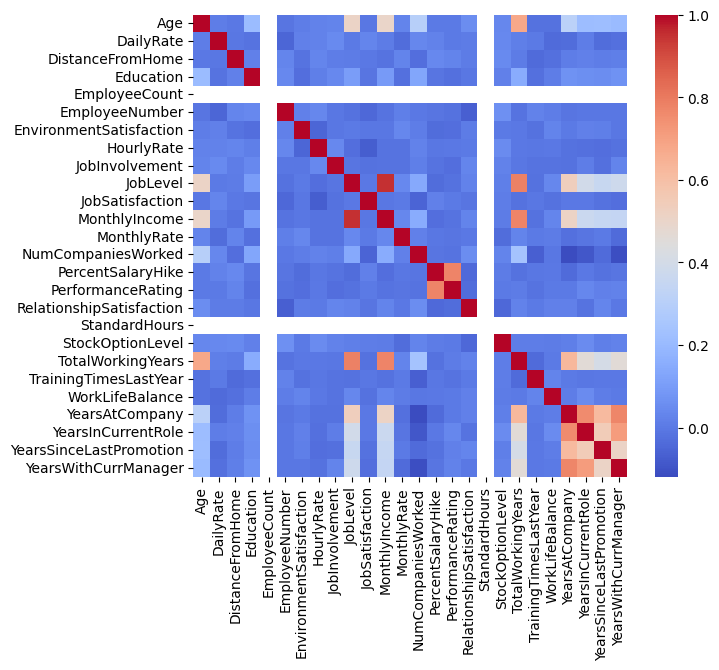

In [ ]:
plt.figure(figsize=(7,6))
sns.heatmap(train.corr(numeric_only=True), cmap='coolwarm')
plt.show()

# Fase 4 - Modellazione
* Confrontare modelli diversi
* Minimo: 3 modelli, di cui almeno 1 lineare (es. regressione) e 1 non lineare (es. kNN, Random Forest)

NB. train/test split e codifica delle variabili categoriche a nostro carico

# Fase 5 - Valutazione e interpretazione dei risultati
* Per ogni modello: accuracy, confusion matrix, precision, recall, f1-score
* Riflessioni: punti di forza, limiti, interpretabilità, tipo di errori, costo computazionale
* Approfondimenti possibili: feature importance (RF), coefficienti (regressione logistica)

# Fase 6 - Report scientifico in LaTeX (Overleaf)
* Lunghezza indicativa: ~6 pagine
* Caricare su GitHub (cartella report/ ) sia il PDF finale che tutti i sorgenti Overleaf (file .tex, immagini, bibliografia, ecc.)
* Sezioni tipiche: Introduzione, Dataset, Metodologia, Risultati, Discussione, Conclusioni
* Elementi obbligatori: ≥2 figure, ≥1 tabella, ≥1 formula, bibliografia, link al repository GitHub